Made to inspect models that have been trained.

Reads the most recent training run from results/training

## Libraries

In [23]:
import csv
import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path
import os
from training.dataset import BRICKDataset
from models.brick import BRICK

os.chdir(r"C:\Users\USER\Documents\GitHub\LIFUS-BRICK")

## Load Data

In [25]:
RUN_INDEX = 3  # <-- change this

# -------------------------------------------------------
# List available runs and pick one
# -------------------------------------------------------
results_root = Path("results/training")
csv_files = sorted(results_root.glob("*/loss_history.csv"))

if not csv_files:
    raise FileNotFoundError("No loss_history.csv found. Run training first.")

print("Available runs:")
for i, f in enumerate(csv_files):
    print(f"  [{i}] {f.parent.name}")


csv_path = csv_files[RUN_INDEX]
print(f"\nPlotting: {csv_path.parent.name}")
 
# -------------------------------------------------------
# Load CSV
# -------------------------------------------------------
epochs       = []
train_total  = []; val_total   = []
train_recon  = []; val_recon   = []
train_kl_g0  = []; val_kl_g0  = []
train_kl_u   = []; val_kl_u   = []
train_cls    = []; val_cls     = []
 
with open(csv_path) as f:
    for row in csv.DictReader(f):
        epochs.append(int(row["epoch"]))
        train_total.append(float(row["train_loss_total"]))
        val_total.append(float(row["val_loss_total"]))
        train_recon.append(float(row["train_loss_recon"]))
        val_recon.append(float(row["val_loss_recon"]))
        train_kl_g0.append(float(row["train_loss_kl_g0"]))
        val_kl_g0.append(float(row["val_loss_kl_g0"]))
        train_kl_u.append(float(row["train_loss_kl_u"]))
        val_kl_u.append(float(row["val_loss_kl_u"]))
        train_cls.append(float(row["train_loss_cls"]))
        val_cls.append(float(row["val_loss_cls"]))

Available runs:
  [0] train_20260618_143928
  [1] train_20260618_144852
  [2] train_20260619_125015
  [3] train_20260619_134312

Plotting: train_20260619_134312


## Plot

Saved to results\figures\training_curves.png


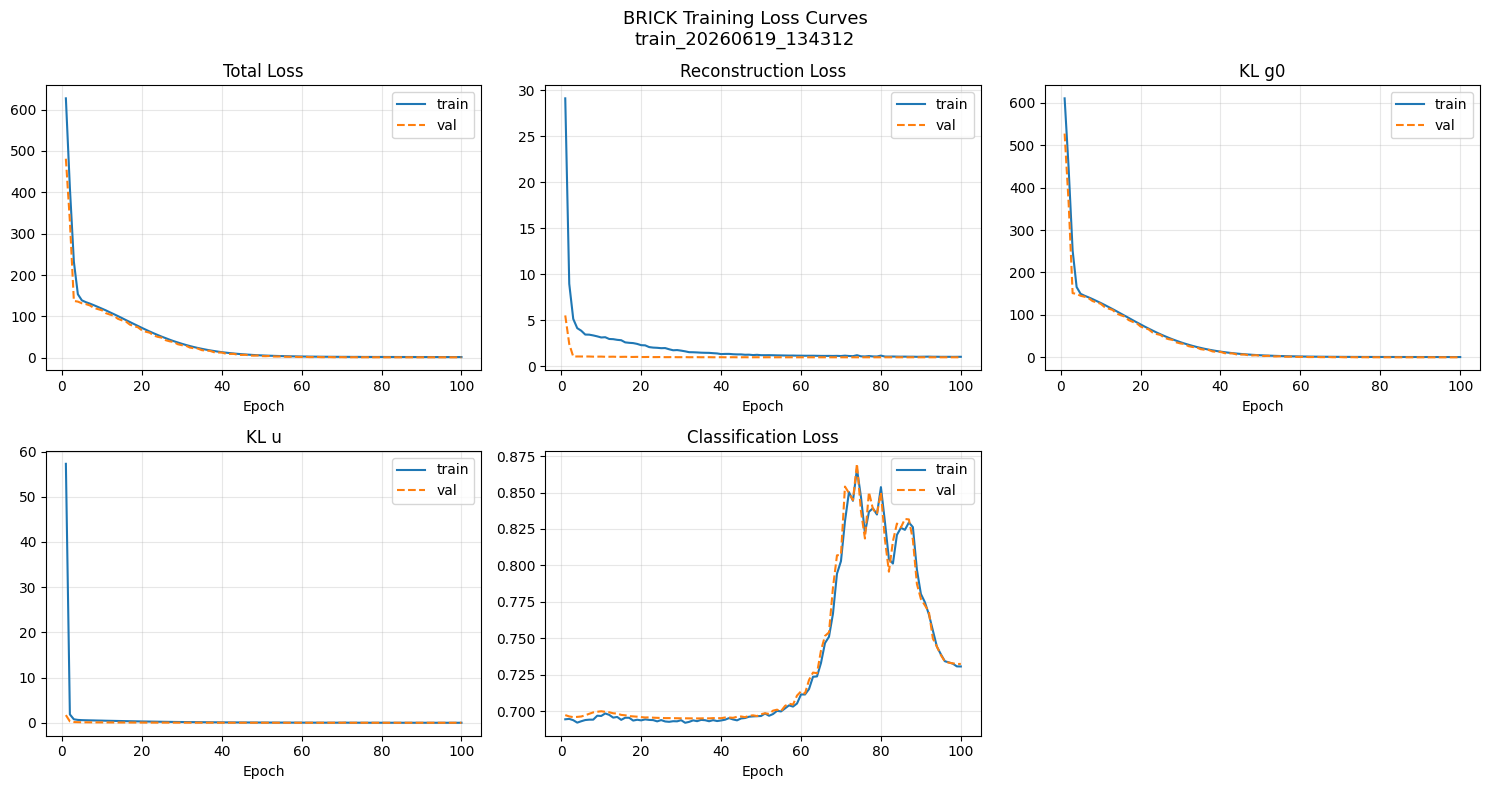

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(f"BRICK Training Loss Curves\n{csv_path.parent.name}", fontsize=13)
 
def plot(ax, title, train, val=None):
    ax.plot(epochs, train, label="train", linewidth=1.5)
    if val is not None:
        ax.plot(epochs, val, label="val", linewidth=1.5, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)
 
plot(axes[0, 0], "Total Loss",            train_total,  val_total)
plot(axes[0, 1], "Reconstruction Loss",   train_recon,  val_recon)
plot(axes[0, 2], "KL g0",                 train_kl_g0,  val_kl_g0)
plot(axes[1, 0], "KL u",                  train_kl_u,   val_kl_u)
plot(axes[1, 1], "Classification Loss",   train_cls,    val_cls)
axes[1, 2].axis("off")
 
plt.tight_layout()
 
# Save
out_path = Path(f"results/figures/training_curves_{csv_path.parent.name}.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved to {out_path}")
plt.show()

One concrete check before you change anything: confirm the recon floor in pic 2 actually equals the data variance. If z-scored BOLD has per-feature variance 1 and recon plateaus at ~1.0, that's quantitative confirmation the decoder is predicting the mean and the latent is doing nothing. If it plateaus meaningfully below 1, the latent is still carrying some information and the collapse is partial. That single number tells you how total the collapse is.

Mean per-feature variance across dataset: 1.0000
Expected recon floor if predicting mean:  1.0000

Found 4 checkpoints:
  [0] train_20260618_143928
  [1] train_20260618_144852
  [2] train_20260619_125015
  [3] train_20260619_134312

Actual recon loss (best model):           0.9958
Recon floor (predicting mean):            1.0000
Ratio recon/floor:                        0.9958

-> Recon is at the floor. Decoder is predicting the mean. Total collapse.


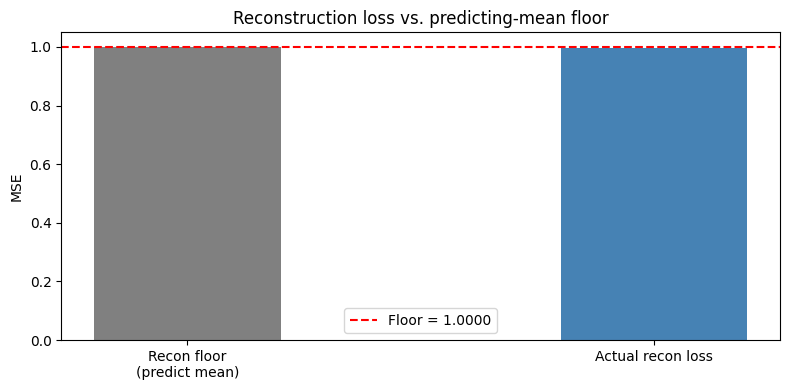

Saved to results/figures/recon_floor_check.png


In [27]:
# --- Load dataset ---
ds = BRICKDataset(Path("data/preprocessed_data"))

# --- Compute mean variance across all items ---
variances = []
for i in range(len(ds)):
    x = ds[i]["x"]  # (T, N), already z-scored
    variances.append(x.var(dim=0).mean().item())  # mean variance across ROIs

mean_variance = np.mean(variances)
print(f"Mean per-feature variance across dataset: {mean_variance:.4f}")
print(f"Expected recon floor if predicting mean:  {mean_variance:.4f}")

# --- Load best model and compute actual recon loss ---
checkpoint_files = sorted(Path("results/training").glob("train_2026061*/best_model.pt"))

print(f"\nFound {len(checkpoint_files)} checkpoints:")
for i, f in enumerate(checkpoint_files):
    print(f"  [{i}] {f.parent.name}")

RUN_INDEX = 1  # <-- change this to the normalized run

checkpoint = torch.load(checkpoint_files[RUN_INDEX], map_location="cpu")
model = BRICK()
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

recon_losses = []
with torch.no_grad():
    for i in range(len(ds)):
        item = ds[i]
        out = model(item["x"], item["lifus_condition"])
        recon_losses.append(out["losses"]["loss_recon"].item())

mean_recon = np.mean(recon_losses)
print(f"\nActual recon loss (best model):           {mean_recon:.4f}")
print(f"Recon floor (predicting mean):            {mean_variance:.4f}")
print(f"Ratio recon/floor:                        {mean_recon/mean_variance:.4f}")

if mean_recon / mean_variance > 0.95:
    print("\n-> Recon is at the floor. Decoder is predicting the mean. Total collapse.")
else:
    print(f"\n-> Recon is {(1 - mean_recon/mean_variance)*100:.1f}% below floor. Latent carries some information.")

# --- Plot ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Recon floor\n(predict mean)", "Actual recon loss"],
       [mean_variance, mean_recon],
       color=["gray", "steelblue"], width=0.4)
ax.axhline(mean_variance, color="red", linestyle="--", label=f"Floor = {mean_variance:.4f}")
ax.set_ylabel("MSE")
ax.set_title("Reconstruction loss vs. predicting-mean floor")
ax.legend()
plt.tight_layout()
plt.savefig("results/figures/recon_floor_check.png", dpi=150)
plt.show()
print("Saved to results/figures/recon_floor_check.png")